# Movie Box-Office Success Predictor — Exploratory Data Analysis

**Author:** Bennett Speicher
**Course:** DATA 606 Capstone (Summer 2026), UMBC — Dr. Chaojie (Jay) Wang

This notebook is the **complete exploratory data analysis (EDA)** for a capstone project that predicts whether a
film will be a **financial success** using only information knowable *before* it is released.

**Definition of success (target):** a movie is a *success* if its worldwide box-office
**revenue is at least 2× its production budget** (`revenue >= 2 * budget`). This 2× rule is a standard industry
proxy for theatrical break-even: marketing typically costs roughly half-to-equal the production budget again, and
theaters keep about half of the box-office gross — so a film must gross about twice its budget to make money.

*Caveat:* TMDB `revenue` is worldwide box-office gross and `budget` excludes marketing, so this target is a
well-grounded **proxy** for profitability, not exact accounting profit.

**Focus of this EDA:** in addition to the standard exploration, this notebook pays special attention to
**release timing** — the season, month, and industry release window a film opens in — and how timing interacts
with genre (e.g., horror around Halloween, family films over the holidays, action/adventure in summer).


### Notebook roadmap
1. Load the data
2. Data quality: structure & missing values
3. Data cleaning & feature engineering (incl. seasonality features)
4. The target variable
5. Univariate analysis (numeric & categorical)
6. Bivariate analysis vs. success
7. **Release timing & seasonality** (season, month, window)
8. **Genre × timing interactions**
9. Correlation analysis
10. Key takeaways & implications for modeling

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import json

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

# Render Plotly figures as static PNGs so every chart displays on GitHub's notebook viewer.
pio.renderers.default = "png"

pd.set_option("display.max_columns", 30)
pd.options.display.float_format = lambda x: f"{x:,.2f}"

# A small, consistent color scheme used throughout
COL_SUCCESS = "#2E7D32"   # green  = success
COL_FAIL    = "#D1495B"   # red    = not successful
COL_ACCENT  = "#E50914"   # crimson accent


## 1. Load the data
We read the TMDB 5000 movie dataset. Each row is a single movie.

In [2]:
# Load the raw dataset (one row per movie)
df = pd.read_csv("../data/tmdb_5000_movies.csv")
print("Raw shape (rows, columns):", df.shape)
df.head(3)


Raw shape (rows, columns): (4803, 20)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.44,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.00,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.20,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.08,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.00,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.90,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.38,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.00,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.30,4466


## 2. Data quality: structure & missing values
Before cleaning, we inspect column types and how complete each column is.

In [3]:
# Column names, data types, and non-null counts
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

In [4]:
# Quantify missing values so we know which columns are usable
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing.to_frame("missing_count").assign(missing_pct=(missing / len(df) * 100).round(1))


,missing_count,missing_pct
homepage,3091,64.40
tagline,844,17.60
overview,3,0.10
runtime,2,0.00
release_date,1,0.00


**Observations.** `homepage` (~64% missing) and `tagline` (~18% missing) are too sparse to be reliable
predictors and will be dropped. A few rows are missing `runtime` or `release_date`. Importantly, `budget` and
`revenue` have *no* nulls — but in TMDB a value of **`0` is used to mean "unknown,"** which we handle next.

## 3. Data cleaning & feature engineering

Cleaning steps:
1. Keep only films with `status == "Released"`.
2. Keep only rows with a **real budget and revenue** (`> 0`). A `0` means "unknown" and would corrupt the
   budget-relative target and ROI.
3. Drop any rows missing a `release_date` (needed for the timing analysis).
4. Remove duplicate titles if any.

Feature engineering:
- Parse the JSON-encoded columns (`genres`, `production_companies`, `spoken_languages`).
- Financial: `roi`, `profit`, and the binary `success` target.
- Timing: `year`, `month`, `season`, and an industry `release_window`.
- Genre-timing interaction flags: summer action/adventure, October horror, holiday family/animation.


In [5]:
def parse_names(json_str):
    """Extract the list of 'name' values from a TMDB JSON-encoded cell (e.g. genres)."""
    try:
        return [d["name"] for d in json.loads(json_str)]
    except Exception:
        return []

# --- Row filtering -------------------------------------------------------
clean = df[df["status"] == "Released"].copy()                     # released films only
clean = clean[(clean["budget"] > 0) & (clean["revenue"] > 0)]     # drop unknown (0) budget/revenue
clean = clean.dropna(subset=["release_date"]).copy()              # need a release date for timing
clean = clean.drop_duplicates(subset=["title", "release_date"])   # guard against duplicate rows

# --- Parse JSON columns into simple values ------------------------------
clean["genre_list"]   = clean["genres"].apply(parse_names)
clean["primary_genre"] = clean["genre_list"].apply(lambda g: g[0] if g else "Unknown")
clean["n_genres"]      = clean["genre_list"].apply(len)
clean["n_production_companies"] = clean["production_companies"].apply(lambda s: len(parse_names(s)))
clean["n_spoken_languages"]     = clean["spoken_languages"].apply(lambda s: len(parse_names(s)))
clean["is_english"] = (clean["original_language"] == "en").astype(int)

# --- Dates & financial features -----------------------------------------
clean["release_date"] = pd.to_datetime(clean["release_date"], errors="coerce")
clean["year"]  = clean["release_date"].dt.year
clean["month"] = clean["release_date"].dt.month

clean["roi"]     = clean["revenue"] / clean["budget"]            # return on budget
clean["profit"]  = clean["revenue"] - clean["budget"]
clean["success"] = (clean["revenue"] >= 2 * clean["budget"]).astype(int)   # <-- TARGET

# --- Timing features -----------------------------------------------------
def to_season(m):
    """Map a month number to a calendar season."""
    if m in (12, 1, 2):  return "Winter"
    if m in (3, 4, 5):   return "Spring"
    if m in (6, 7, 8):   return "Summer"
    return "Fall"                                    # 9, 10, 11

def to_window(m):
    """Map a month to an industry release window."""
    if m in (5, 6, 7, 8):  return "Summer blockbuster (May-Aug)"
    if m in (11, 12):      return "Holiday (Nov-Dec)"
    if m in (1, 2):        return "Dump months (Jan-Feb)"
    if m in (9, 10):       return "Fall (Sep-Oct)"
    return "Spring (Mar-Apr)"

clean["season"]         = clean["month"].apply(to_season)
clean["release_window"] = clean["month"].apply(to_window)

# --- Genre x timing interaction flags -----------------------------------
def has_genre(gl, *targets):
    return int(any(t in gl for t in targets))

clean["is_summer_action_adv"] = clean.apply(
    lambda r: int(has_genre(r["genre_list"], "Action", "Adventure") and r["month"] in (5, 6, 7)), axis=1)
clean["is_october_horror"] = clean.apply(
    lambda r: int(has_genre(r["genre_list"], "Horror") and r["month"] == 10), axis=1)
clean["is_holiday_family"] = clean.apply(
    lambda r: int(has_genre(r["genre_list"], "Family", "Animation") and r["month"] in (11, 12)), axis=1)

print(f"Rows before cleaning: {len(df):,}")
print(f"Rows after cleaning : {len(clean):,}  ({len(clean)/len(df)*100:.1f}% retained)")
print(f"Release years       : {int(clean['year'].min())}–{int(clean['year'].max())}")
print(f"Success rate        : {clean['success'].mean()*100:.1f}%")
clean[["title","budget","revenue","roi","primary_genre","month","season","release_window","success"]].head()


Rows before cleaning: 4,803
Rows after cleaning : 3,228  (67.2% retained)
Release years       : 1916–2016
Success rate        : 56.0%


,title,budget,revenue,roi,primary_genre,month,season,release_window,success
0,Avatar,237000000,2787965087,11.76,Action,12,Winter,Holiday (Nov-Dec),1
1,Pirates of the Caribbean: At World's End,300000000,961000000,3.20,Adventure,5,Spring,Summer blockbuster (May-Aug),1
2,Spectre,245000000,880674609,3.59,Action,10,Fall,Fall (Sep-Oct),1
3,The Dark Knight Rises,250000000,1084939099,4.34,Action,7,Summer,Summer blockbuster (May-Aug),1
4,John Carter,260000000,284139100,1.09,Action,3,Spring,Spring (Mar-Apr),0


## 4. The target variable
A balanced target makes for a cleaner classification problem and more meaningful metrics.

success
Successful (>=2x)       1809
Not Successful (<2x)    1419
Name: count, dtype: int64

Success rate: 56.0%


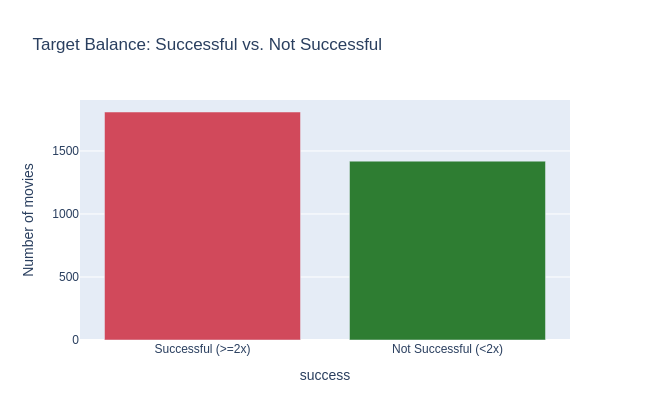

In [6]:
# Class balance of the success target
counts = clean["success"].map({0: "Not Successful (<2x)", 1: "Successful (>=2x)"}).value_counts()
print(counts)
print(f"\nSuccess rate: {clean['success'].mean()*100:.1f}%")

fig = px.bar(counts, x=counts.index, y=counts.values,
             title="Target Balance: Successful vs. Not Successful",
             labels={"x": "", "y": "Number of movies"},
             color=counts.index, color_discrete_sequence=[COL_FAIL, COL_SUCCESS])
fig.update_layout(showlegend=False, width=650, height=420)
fig.show()


## 5. Univariate analysis
### 5.1 Numeric features
Summary statistics, then distributions. Budget and revenue are highly right-skewed, so we use log scales.

In [7]:
# Summary statistics for the key numeric fields
clean[["budget","revenue","roi","runtime","popularity","vote_average","vote_count","n_genres"]].describe()


,budget,revenue,roi,runtime,popularity,vote_average,vote_count,n_genres
count,"3,228.00","3,228.00","3,228.00","3,228.00","3,228.00","3,228.00","3,228.00","3,228.00"
mean,"40,666,419.51","121,280,256.28","2,955.74",110.72,29.04,6.31,977.59,2.65
std,"44,398,404.53","186,319,669.51","150,633.42",20.97,36.17,0.87,"1,414.43",1.12
min,1.00,5.00,0.00,41.00,0.02,0.00,0.00,0.00
25%,"10,500,000.00","17,000,000.00",1.02,96.00,10.47,5.80,178.00,2.00
50%,"25,000,000.00","55,191,503.00",2.30,107.00,20.41,6.30,471.00,3.00
75%,"55,000,000.00","146,343,449.50",4.42,121.00,37.34,6.90,"1,148.00",3.00
max,"380,000,000.00","2,787,965,087.00","8,500,000.00",338.00,875.58,8.50,"13,752.00",7.00


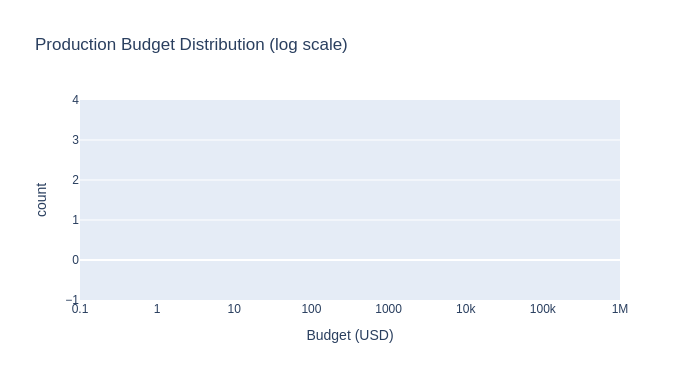

In [8]:
# Budget distribution (log scale to handle the heavy right skew)
fig = px.histogram(clean, x="budget", nbins=50, title="Production Budget Distribution (log scale)",
                   labels={"budget": "Budget (USD)"})
fig.update_xaxes(type="log")
fig.update_layout(width=700, height=380)
fig.show()


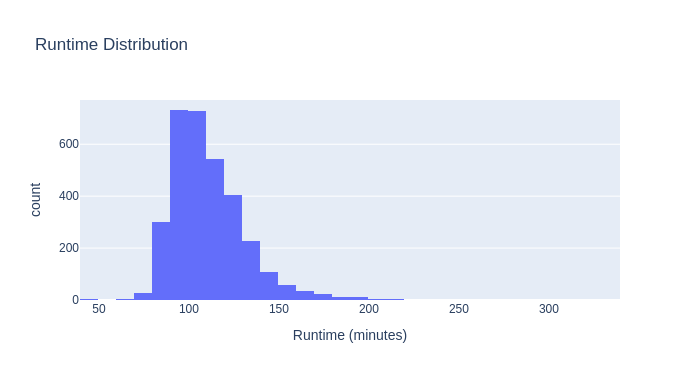

In [9]:
# Runtime distribution — most films cluster around 90-120 minutes
fig = px.histogram(clean, x="runtime", nbins=40, title="Runtime Distribution",
                   labels={"runtime": "Runtime (minutes)"})
fig.update_layout(width=700, height=380)
fig.show()


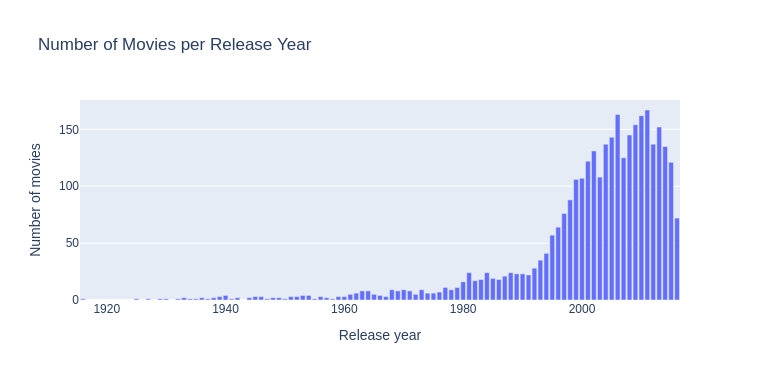

In [10]:
# How many films were released per year (data leans heavily toward 1990s-2010s)
per_year = clean.groupby("year").size().reset_index(name="n")
fig = px.bar(per_year, x="year", y="n", title="Number of Movies per Release Year",
             labels={"year": "Release year", "n": "Number of movies"})
fig.update_layout(width=760, height=380)
fig.show()


### 5.2 Categorical features
Which genres are most common in the dataset?

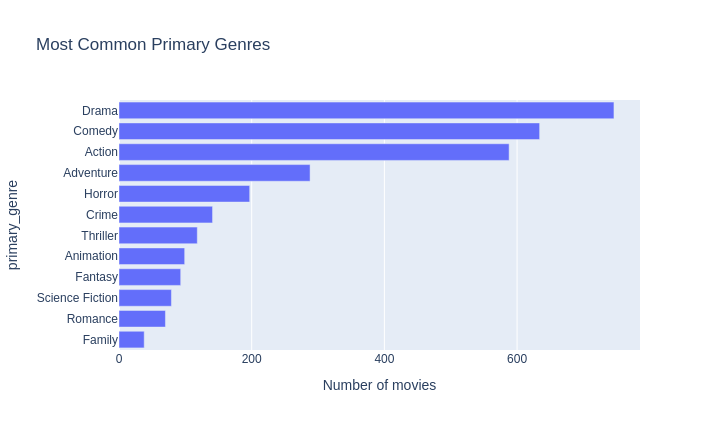

In [11]:
# Frequency of primary genres
genre_counts = clean["primary_genre"].value_counts().head(12)
fig = px.bar(genre_counts, x=genre_counts.values, y=genre_counts.index, orientation="h",
             title="Most Common Primary Genres", labels={"x": "Number of movies", "y": "Primary genre"})
fig.update_layout(width=720, height=430, yaxis={"categoryorder": "total ascending"})
fig.show()


## 6. Bivariate analysis vs. success
### 6.1 Budget vs. revenue
The dashed line is break-even under our definition (`revenue = 2 × budget`). Points above it are successes.

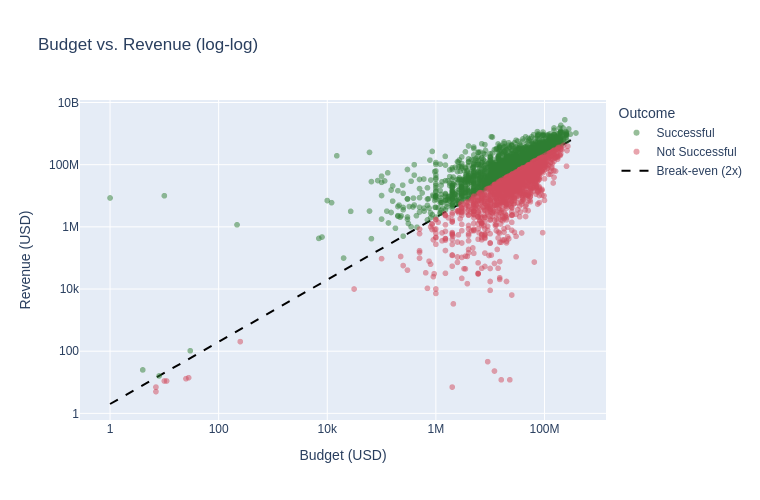

In [12]:
# Scatter of budget vs revenue on log-log axes, colored by outcome, with the 2x break-even line
fig = px.scatter(clean, x="budget", y="revenue",
                 color=clean["success"].map({0: "Not Successful", 1: "Successful"}),
                 opacity=0.5, title="Budget vs. Revenue (log-log)",
                 labels={"budget": "Budget (USD)", "revenue": "Revenue (USD)", "color": "Outcome"},
                 color_discrete_map={"Not Successful": COL_FAIL, "Successful": COL_SUCCESS})
xs = [clean["budget"].min(), clean["budget"].max()]
fig.add_trace(go.Scatter(x=xs, y=[2*xs[0], 2*xs[1]], mode="lines",
                         line=dict(dash="dash", color="black"), name="Break-even (2x)"))
fig.update_xaxes(type="log"); fig.update_yaxes(type="log")
fig.update_layout(width=760, height=500)
fig.show()


### 6.2 Does budget differ between successes and non-successes?

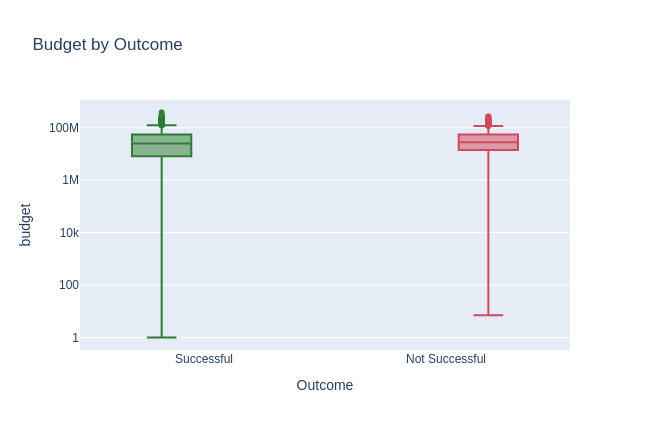

In [13]:
# Budget distribution split by outcome (log y-axis)
fig = px.box(clean, x=clean["success"].map({0: "Not Successful", 1: "Successful"}), y="budget",
             color=clean["success"].map({0: "Not Successful", 1: "Successful"}),
             title="Budget by Outcome", labels={"x": "Outcome", "y": "Budget (USD)"},
             color_discrete_map={"Not Successful": COL_FAIL, "Successful": COL_SUCCESS})
fig.update_yaxes(type="log")
fig.update_layout(showlegend=False, width=650, height=430)
fig.show()


### 6.3 Success rate by genre

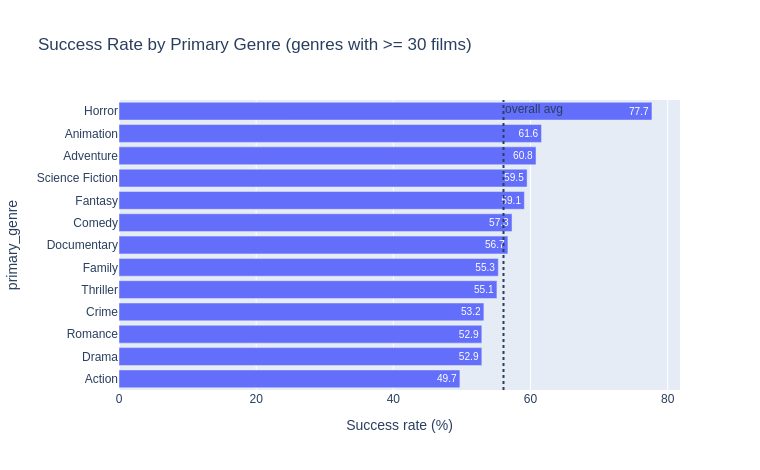

,success_rate,n
primary_genre,,
Horror,77.70,197
Animation,61.60,99
Adventure,60.80,288
Science Fiction,59.50,79
Fantasy,59.10,93
Comedy,57.30,634
Documentary,56.70,30
Family,55.30,38
Thriller,55.10,118


In [14]:
# Success rate by primary genre (only genres with a reasonable sample size)
genre_stats = (clean.groupby("primary_genre")
               .agg(success_rate=("success", "mean"), n=("success", "size"))
               .query("n >= 30").sort_values("success_rate", ascending=False))
genre_stats["success_rate"] = (genre_stats["success_rate"] * 100).round(1)
fig = px.bar(genre_stats, x="success_rate", y=genre_stats.index, orientation="h",
             title="Success Rate by Primary Genre (genres with >= 30 films)",
             labels={"success_rate": "Success rate (%)", "y": "Primary genre"}, text="success_rate")
fig.add_vline(x=clean["success"].mean()*100, line_dash="dot", annotation_text="overall avg")
fig.update_layout(width=760, height=470, yaxis={"categoryorder": "total ascending"})
fig.show()
genre_stats


## 7. Release timing & seasonality

This is a central question for the project: **does *when* a film is released relate to its success?**
Studios concentrate their biggest films in summer and over the winter holidays, and avoid the early-fall
"dump" window. We test that directly.

### 7.1 Success rate by month (with release volume)

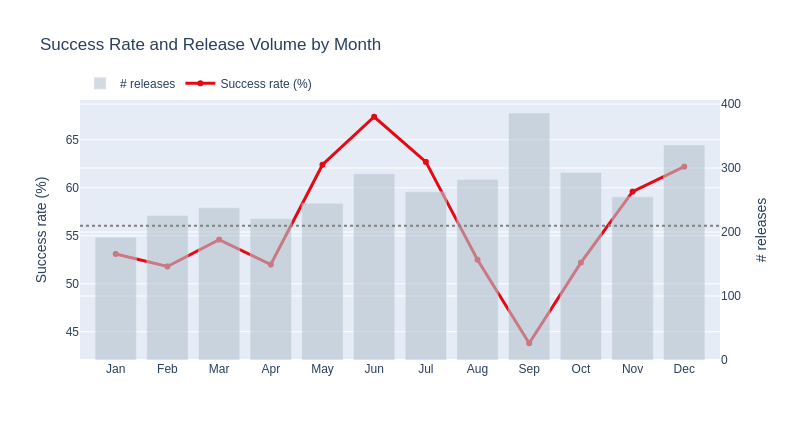

In [15]:
# Success rate AND number of releases per month, on one figure with two axes
month_names = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}
m = (clean.groupby("month").agg(success_rate=("success","mean"), n=("success","size")).reset_index())
m["month_name"] = m["month"].map(month_names)
m["success_rate"] = (m["success_rate"] * 100).round(1)

fig = go.Figure()
# bars = number of releases (volume / competition)
fig.add_trace(go.Bar(x=m["month_name"], y=m["n"], name="# releases", marker_color="#B7C4CF", yaxis="y2", opacity=0.6))
# line = success rate
fig.add_trace(go.Scatter(x=m["month_name"], y=m["success_rate"], name="Success rate (%)",
                         mode="lines+markers", line=dict(color=COL_ACCENT, width=3)))
fig.add_hline(y=clean["success"].mean()*100, line_dash="dot", line_color="gray")
fig.update_layout(title="Success Rate and Release Volume by Month",
                  yaxis=dict(title="Success rate (%)"), yaxis2=dict(title="# releases", overlaying="y", side="right"),
                  width=800, height=440, legend=dict(orientation="h", y=1.12))
fig.show()


### 7.2 Success rate by season

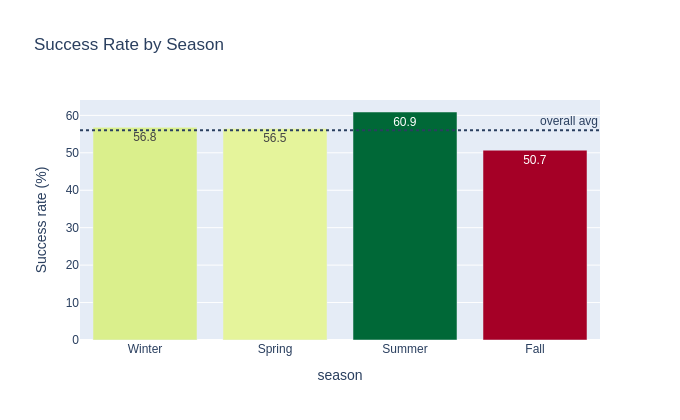

,success_rate,n,median_roi
season,,,
Winter,56.80,754,2.40
Spring,56.50,704,2.31
Summer,60.90,836,2.59
Fall,50.70,934,2.03


In [16]:
# Success rate by calendar season
s = (clean.groupby("season").agg(success_rate=("success","mean"), n=("success","size"), median_roi=("roi","median"))
     .reindex(["Winter","Spring","Summer","Fall"]))
s["success_rate"] = (s["success_rate"] * 100).round(1)
fig = px.bar(s, x=s.index, y="success_rate", title="Success Rate by Season", text="success_rate",
             labels={"x": "Season", "success_rate": "Success rate (%)"},
             color="success_rate", color_continuous_scale="RdYlGn")
fig.add_hline(y=clean["success"].mean()*100, line_dash="dot", annotation_text="overall avg")
fig.update_layout(width=680, height=420, coloraxis_showscale=False)
fig.show()
s


### 7.3 Success rate by industry release window
Grouping months the way the film industry actually thinks about the calendar.

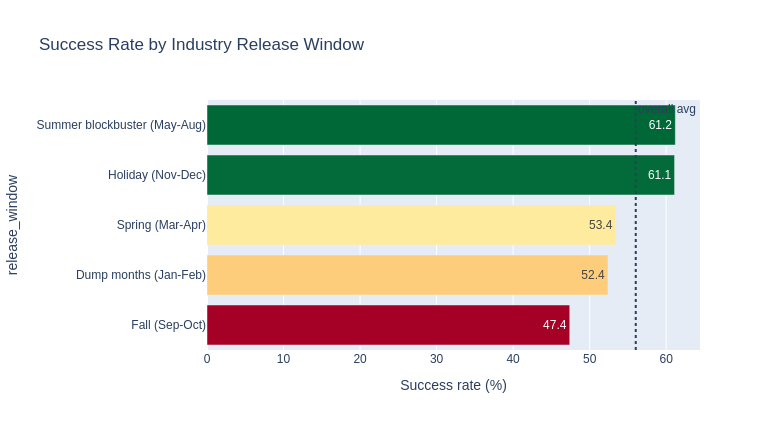

,success_rate,n,median_roi
release_window,,,
Summer blockbuster (May-Aug),61.20,1081,2.62
Holiday (Nov-Dec),61.10,591,2.64
Spring (Mar-Apr),53.40,459,2.13
Dump months (Jan-Feb),52.40,418,2.10
Fall (Sep-Oct),47.40,679,1.89


In [17]:
# Success rate by industry release window
w = (clean.groupby("release_window").agg(success_rate=("success","mean"), n=("success","size"), median_roi=("roi","median"))
     .sort_values("success_rate", ascending=False))
w["success_rate"] = (w["success_rate"] * 100).round(1)
fig = px.bar(w, x="success_rate", y=w.index, orientation="h", text="success_rate",
             title="Success Rate by Industry Release Window",
             labels={"success_rate": "Success rate (%)", "y": "Release window"},
             color="success_rate", color_continuous_scale="RdYlGn")
fig.add_vline(x=clean["success"].mean()*100, line_dash="dot", annotation_text="overall avg")
fig.update_layout(width=780, height=430, yaxis={"categoryorder": "total ascending"}, coloraxis_showscale=False)
fig.show()
w


**Interpretation.** The **Summer (May–Aug)** and **Holiday (Nov–Dec)** windows both run ~61% success,
clearly above the 56% baseline, while **early Fall (Sep–Oct)** is the weakest at ~47% — with **September the
single worst month**. This matches the industry's real behavior: tentpoles go to summer and the holidays, and
early fall is the "dump" season.

## 8. Genre × timing interactions
Timing effects are strongest for *specific genres in specific windows*.

### 8.1 Horror releases by month (the Halloween effect)

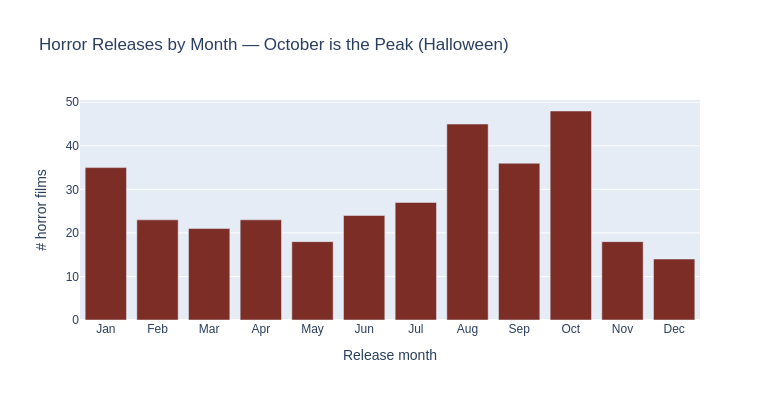

Horror films: 332 | overall horror success: 67.2%
October horror success: 70.8%  vs other months: 66.5%


In [18]:
# Where do horror films release, and does October help?
horror = clean[clean["genre_list"].apply(lambda g: "Horror" in g)]
hb = (horror.groupby("month").agg(n=("success","size"), success_rate=("success","mean")).reset_index())
hb["month_name"] = hb["month"].map(month_names)
hb["success_rate"] = (hb["success_rate"] * 100).round(1)

fig = go.Figure()
fig.add_trace(go.Bar(x=hb["month_name"], y=hb["n"], name="# horror releases", marker_color="#7B2D26"))
fig.update_layout(title="Horror Releases by Month — October is the Peak (Halloween)",
                  xaxis_title="Release month", yaxis_title="# horror films", width=780, height=400)
fig.show()

oct_h = horror[horror["month"] == 10]["success"].mean() * 100
other_h = horror[horror["month"] != 10]["success"].mean() * 100
print(f"Horror films: {len(horror)} | overall horror success: {horror['success'].mean()*100:.1f}%")
print(f"October horror success: {oct_h:.1f}%  vs other months: {other_h:.1f}%")


### 8.2 Genre-timing comparisons
Three targeted comparisons: family/animation over the holidays, action/adventure in summer, and horror in October — each vs. the rest of the year.

In [19]:
# Build a tidy comparison table: each genre-timing bet vs. the rest of the year
def compare(mask_genre, mask_time, label):
    grp = clean[mask_genre]
    in_window  = grp[mask_time.loc[grp.index]]["success"].mean() * 100
    out_window = grp[~mask_time.loc[grp.index]]["success"].mean() * 100
    return {"Genre-timing bet": label,
            "In window (%)": round(in_window, 1),
            "Rest of year (%)": round(out_window, 1),
            "Lift (pp)": round(in_window - out_window, 1)}

is_fam   = clean["genre_list"].apply(lambda g: ("Family" in g) or ("Animation" in g))
is_aa    = clean["genre_list"].apply(lambda g: ("Action" in g) or ("Adventure" in g))
is_hor   = clean["genre_list"].apply(lambda g: "Horror" in g)
holiday  = clean["month"].isin([11, 12])
summer   = clean["month"].isin([5, 6, 7])
october  = clean["month"].eq(10)

rows = [
    compare(is_fam, holiday, "Family/Animation in Holiday (Nov-Dec)"),
    compare(is_aa,  summer,  "Action/Adventure in Summer (May-Jul)"),
    compare(is_hor, october, "Horror in October"),
]
comp = pd.DataFrame(rows)
comp


,Genre-timing bet,In window (%),Rest of year (%),Lift (pp)
0,Family/Animation in Holiday (Nov-Dec),68.20,57.90,10.30
1,Action/Adventure in Summer (May-Jul),64.00,49.90,14.00
2,Horror in October,70.80,66.50,4.30


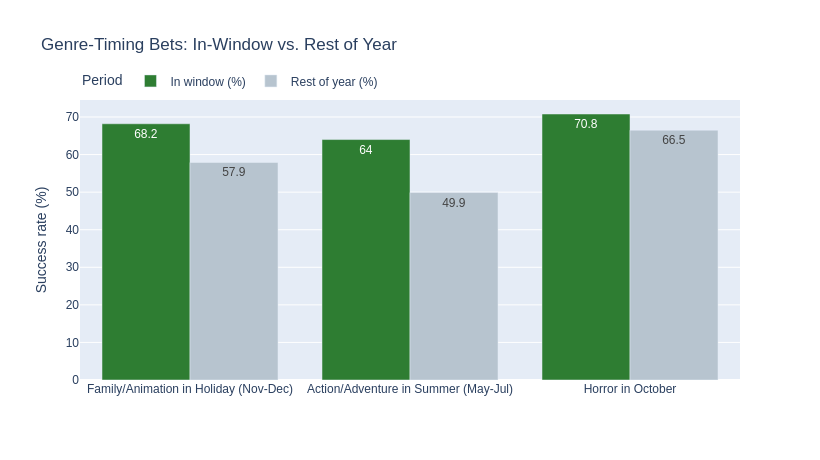

In [20]:
# Visualize the in-window vs rest-of-year comparison
plot_df = comp.melt(id_vars="Genre-timing bet", value_vars=["In window (%)", "Rest of year (%)"],
                    var_name="Period", value_name="Success rate (%)")
fig = px.bar(plot_df, x="Genre-timing bet", y="Success rate (%)", color="Period", barmode="group",
             title="Genre-Timing Bets: In-Window vs. Rest of Year",
             color_discrete_sequence=[COL_SUCCESS, "#B7C4CF"], text="Success rate (%)")
fig.update_layout(width=820, height=460, xaxis_title="", legend=dict(orientation="h", y=1.12))
fig.show()


### 8.3 Genre × season success-rate heatmap

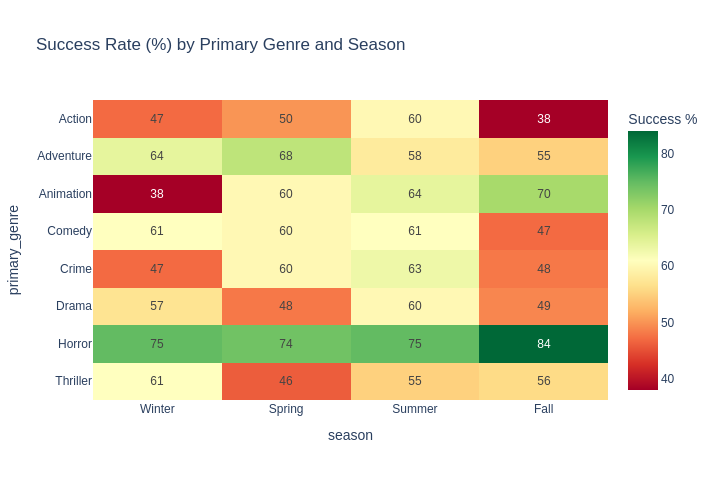

In [21]:
# Heatmap: success rate for each (primary genre, season) combination (cells with enough films)
top_genres = clean["primary_genre"].value_counts().head(8).index
sub = clean[clean["primary_genre"].isin(top_genres)]
pivot_rate = sub.pivot_table(index="primary_genre", columns="season", values="success", aggfunc="mean")
pivot_n    = sub.pivot_table(index="primary_genre", columns="season", values="success", aggfunc="size")
pivot_rate = pivot_rate[["Winter","Spring","Summer","Fall"]].mask(pivot_n < 10)  # hide tiny cells
fig = px.imshow((pivot_rate*100).round(0), text_auto=True, aspect="auto", color_continuous_scale="RdYlGn",
                title="Success Rate (%) by Primary Genre and Season",
                labels=dict(color="Success %"))
fig.update_layout(width=720, height=480)
fig.show()


## 9. Correlation analysis
How numeric features relate to each other and to success.

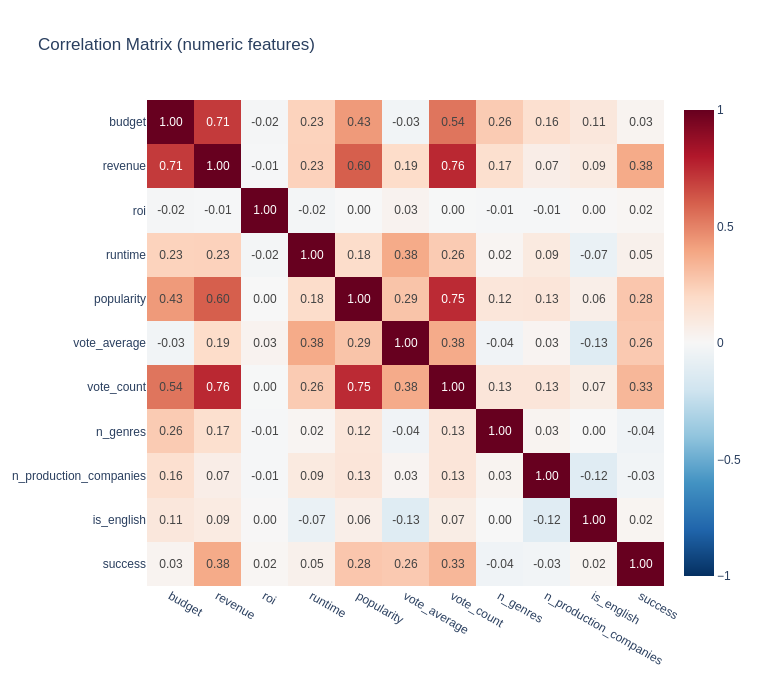

In [22]:
# Correlation matrix of numeric features (includes some post-release fields for context only)
num_cols = ["budget","revenue","roi","runtime","popularity","vote_average","vote_count",
            "n_genres","n_production_companies","is_english","success"]
corr = clean[num_cols].corr()
fig = px.imshow(corr, text_auto=".2f", aspect="auto", color_continuous_scale="RdBu_r",
                zmin=-1, zmax=1, title="Correlation Matrix (numeric features)")
fig.update_layout(width=760, height=680)
fig.show()


## 10. Key takeaways & implications for modeling

**Data preparation.** From 4,803 raw movies we keep **~3,200** released films that have a real budget and
revenue (dropping the ~33% where a `0` means "unknown"), parse the JSON columns, and engineer financial and
timing features. The result is a tidy table with one row per movie and a balanced target.

**What predicts success (signal we found):**
- **Budget** relates to revenue but is far from deterministic — many big-budget films still miss break-even.
- **Genre** matters: Horror, Animation, and Adventure tend to clear the 2× bar more often than Drama.
- **Release timing is real signal.** Summer (May–Aug) and Holiday (Nov–Dec) windows beat the ~56% baseline
  (~61% each); early Fall (Sep–Oct) is worst (~47%), September the weakest month.
- **Genre × timing is even stronger:** Action/Adventure in summer (~64% vs ~50%), Family/Animation over the
  holidays (~68% vs ~58%), and horror concentrated in October (its single biggest release month).

**Features for the model (pre-release only, no leakage):** `budget`, `primary_genre`, `runtime`,
`release month` / `season` / `release_window`, `original_language` / `is_english`, `n_production_companies`,
`n_spoken_languages`, and the genre-timing flags engineered above.

**Excluded to prevent leakage** (post-release outcomes): `revenue`, `roi`, `profit`, `popularity`,
`vote_average`, `vote_count`.

**Next step (Assignment 4 / modeling):** encode categorical features, do an 80/20 train/test split, and compare
logistic regression, random forest, and gradient boosting — then deploy the best model in a Streamlit app.
